<a href="https://colab.research.google.com/github/khushibarali13-sudo/Multimodal-Analysis-of-Parkinsons-Disease-using-MRI-and-EEG---A-Deep-Learning-Approach/blob/main/Resnet_18_architecture_k_fold_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing libaries

In [ ]:
!pip install pydicom torch torchvision scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 37.0 MB/s eta 0:00:00


loading the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
parkinson_zip_path = "/content/drive/MyDrive/Parkinson MRI dataset.zip"
control_zip_path   = "/content/drive/MyDrive/controlled MRI dataset.zip"
csv_path1          = "/content/drive/MyDrive/new_Mri_2_22_2026.csv"
csv_path2          = "/content/drive/MyDrive/controlled_MRI_scan_2_22_2026.csv"

In [ ]:
import shutil
import os

files_to_copy = [
    (parkinson_zip_path, "Mri.zip"),
    (control_zip_path, "controlled MRI scan_dataset.zip"),
    (csv_path1, "new_Mri_2_22_2026.csv"),
    (csv_path2, "controlled_MRI_scan_2_22_2026.csv")
]

all_copied_successfully = True
for src_path, file_name in files_to_copy:
    if os.path.exists(src_path):
        try:
            shutil.copy(src_path, "/content/")
            print(f"Successfully copied {file_name} to /content/.")
        except Exception as e:
            print(f"Error copying {file_name} from {src_path}: {e}")
            all_copied_successfully = False
    else:
        print(f"Error: {file_name} not found at {src_path}. Please ensure it exists in your Google Drive.")
        all_copied_successfully = False

if all_copied_successfully:
    print("All specified files were successfully copied to Colab runtime.")
else:
    print("Some files could not be copied. Please check the messages above.")

Error: Mri.zip not found at /content/drive/MyDrive/Mri.zip. Please ensure it exists in your Google Drive.
Error: controlled MRI scan_dataset.zip not found at /content/drive/MyDrive/controlled MRI scan_dataset.zip. Please ensure it exists in your Google Drive.
Error: new_Mri_2_22_2026.csv not found at /content/drive/MyDrive/new_Mri_2_22_2026.csv. Please ensure it exists in your Google Drive.
Successfully copied controlled_MRI_scan_2_22_2026.csv to /content/.
Some files could not be copied. Please check the messages above.


In [ ]:
import zipfile
import os

extract_path = "/content/dataset"
os.makedirs(extract_path, exist_ok=True)

zip_files_to_extract = ["Mri.zip", "controlled MRI scan_dataset.zip"]
copied_zip_files_location = "/content/" # Assuming they are copied here

all_extracted_successfully = True
for zip_file_name in zip_files_to_extract:
    full_zip_path = os.path.join(copied_zip_files_location, zip_file_name)
    if os.path.exists(full_zip_path):
        try:
            with zipfile.ZipFile(full_zip_path, 'r') as zip_ref:
                zip_ref.extractall(extract_path)
            print(f"Successfully extracted {zip_file_name} to {extract_path}.")
        except Exception as e:
            print(f"Error extracting {zip_file_name}: {e}")
            all_extracted_successfully = False
    else:
        print(f"Error: {zip_file_name} not found in {copied_zip_files_location}. Please ensure it was copied there successfully.")
        all_extracted_successfully = False

if all_extracted_successfully:
    print("All specified ZIP files were successfully extracted.")
else:
    print("Some ZIP files could not be extracted. Please check the messages above.")

Error: Mri.zip not found in /content/. Please ensure it was copied there successfully.
Error: controlled MRI scan_dataset.zip not found in /content/. Please ensure it was copied there successfully.
Some ZIP files could not be extracted. Please check the messages above.


In [ ]:
print("Dataset folders:")
print(os.listdir("/content/dataset"))

Dataset folders:
['PPMI']


In [ ]:
import pandas as pd

df = pd.read_csv("/content/new_Mri_2_22_2026.csv")
print(df.head())
df = pd.read_csv("controlled_MRI_scan_2_22_2026.csv")
print(df.head())

  Image Data ID  Subject Group Sex  Age Visit Modality      Description  \
0     I10253274   110219    PD   M   74   V04      MRI       AX GRE -MT   
1     I10253253   105711    PD   M   64   V04      MRI  AXIAL 2D GRE-MT   
2     I10253235   101799    PD   M   64   V06      MRI  AXIAL 2D GRE-MT   
3      I1495912   101748    PD   F   63    BL      MRI     AX T2 GRE MT   
4      I1495907   101748    PD   F   63    BL      MRI     AX T2 GRE MT   

       Type    Acq Date Format Downloaded  
0  Original   6/14/2023    DCM  2/22/2026  
1  Original  10/05/2022    DCM  2/22/2026  
2  Original   6/20/2023    DCM  2/22/2026  
3  Original   7/07/2021    DCM  2/22/2026  
4  Original   7/07/2021    DCM  2/22/2026  
  Image Data ID  Subject    Group Sex  Age Visit Modality   Description  \
0     I10253524   130556  Control   M   73    BL      MRI     2D GRE-MT   
1     I10253528   130556  Control   M   73    BL      MRI     2D GRE-MT   
2      I1621894   157434  Control   F   60    BL      MRI   

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/new_Mri_2_22_2026.csv')

print(df)

df= pd.read_csv('/content/drive/MyDrive/controlled_MRI_scan_2_22_2026.csv')

   Image Data ID  Subject Group Sex  Age Visit Modality      Description  \
0      I10253274   110219    PD   M   74   V04      MRI       AX GRE -MT   
1      I10253253   105711    PD   M   64   V04      MRI  AXIAL 2D GRE-MT   
2      I10253235   101799    PD   M   64   V06      MRI  AXIAL 2D GRE-MT   
3       I1495912   101748    PD   F   63    BL      MRI     AX T2 GRE MT   
4       I1495907   101748    PD   F   63    BL      MRI     AX T2 GRE MT   
..           ...      ...   ...  ..  ...   ...      ...              ...   
95     I10285181   243618    PD   M   73    BL      MRI            NM-MT   
96     I10285228   243963    PD   F   55    BL      MRI        2D GRE-MT   
97     I10285247   244480    PD   M   56    BL      MRI        2D-GRE MT   
98     I10317329   109910    PD   M   57   V06      MRI        2D GRE-MT   
99     I10317384   115680    PD   F   76   V04      MRI   2D GRE-MT_ACPC   

        Type    Acq Date Format Downloaded  
0   Original   6/14/2023    DCM  2/22/2026

In [ ]:
import os

dataset_path = "/content/PPMI/Mri.zip"

def count_dicom_slices(path):
    total_slices = 0
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.lower().endswith(".dcm"):
                total_slices += 1
    return total_slices

total_slices = count_dicom_slices(dataset_path)

print("Total MRI Slices in Dataset:", total_slices)

Total MRI Slices in Dataset: 0


In [ ]:
import os

base_path = "/content/dataset"  # change if different

parkinson_path = os.path.join(base_path, "PPMI")
control_path   = os.path.join(base_path, "PPMI")

In [ ]:
def count_dicom_slices(path):
    count = 0
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.lower().endswith(".dcm"):
                count += 1
    return count

In [ ]:
import os
import pandas as pd # Need to import pandas for reading CSVs

# Define count_dicom_slices function (from cell bels8nLeK4pQ)
def count_dicom_slices(path):
    count = 0
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.lower().endswith(".dcm"):
                count += 1
    return count

pd_slices = 0
control_slices = 0

# Re-define CSV paths and create subject_to_group mapping (using /content/ paths from earlier copies)
csv_path1 = "/content/new_Mri_2_22_2026.csv"
csv_path2 = "/content/controlled_MRI_scan_2_22_2026.csv"

parkinson_df = pd.read_csv(csv_path1)
control_df = pd.read_csv(csv_path2)

subject_to_group = {}
for _, row in parkinson_df.iterrows():
    subject_to_group[row['Subject']] = 'PD'
for _, row in control_df.iterrows():
    subject_to_group[row['Subject']] = 'Control'

# Assuming data_root_path is available from previous steps (TSGW6MIgJj76)
data_root_path = "/content/dataset/PPMI"

# Get a list of all directory names (subject IDs) within data_root_path
subject_dirs = [d for d in os.listdir(data_root_path) if os.path.isdir(os.path.join(data_root_path, d))]

for subject_id_str in subject_dirs:
    try:
        subject_id_int = int(subject_id_str)
        if subject_id_int in subject_to_group: # Check if this subject is in our mapped groups
            group = subject_to_group[subject_id_int]
            subject_folder_path = os.path.join(data_root_path, subject_id_str)

            # count_dicom_slices is defined here
            num_slices_in_subject = count_dicom_slices(subject_folder_path)

            if group == 'PD':
                pd_slices += num_slices_in_subject
            elif group == 'Control':
                control_slices += num_slices_in_subject
    except ValueError:
        # Skip directories that are not valid integer subject IDs
        pass

print("Total Parkinson MRI Slices:", pd_slices)
print("Total Control MRI Slices:", control_slices)
print("Total Slices:", pd_slices + control_slices)


Total Parkinson MRI Slices: 2681
Total Control MRI Slices: 1938
Total Slices: 4619


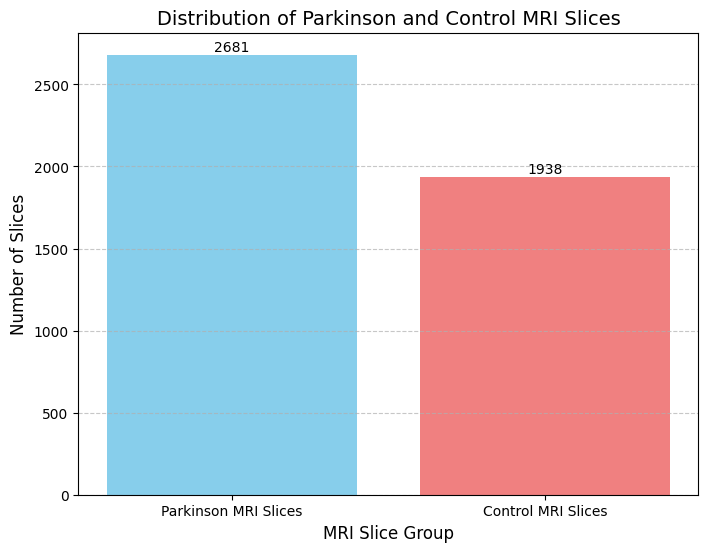

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Data for plotting
data = {
    'Group': ['Parkinson MRI Slices', 'Control MRI Slices'],
    'Count': [pd_slices, control_slices]
}
df_slice_counts = pd.DataFrame(data)

# Create the bar plot
plt.figure(figsize=(8, 6))
plt.bar(df_slice_counts['Group'], df_slice_counts['Count'], color=['skyblue', 'lightcoral'])

# Add labels and title
plt.xlabel('MRI Slice Group', fontsize=12)
plt.ylabel('Number of Slices', fontsize=12)
plt.title('Distribution of Parkinson and Control MRI Slices', fontsize=14)

# Add count values on top of the bars
for index, row in df_slice_counts.iterrows():
    plt.text(index, row['Count'], str(row['Count']), ha='center', va='bottom', fontsize=10)

# Show the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Number of Parkinson's patients with MRI data: 77
Number of Control patients with MRI data: 28


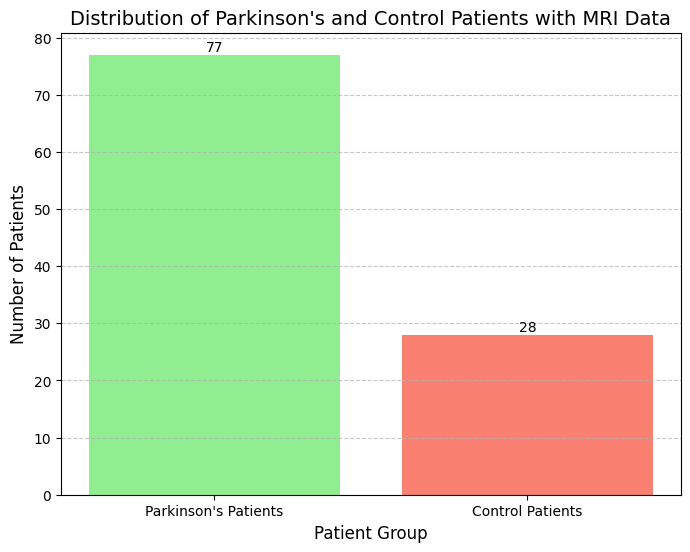

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Re-define CSV paths (using /content/ paths from earlier copies)
csv_path1 = "/content/new_Mri_2_22_2026.csv"
csv_path2 = "/content/controlled_MRI_scan_2_22_2026.csv"

parkinson_df = pd.read_csv(csv_path1)
control_df = pd.read_csv(csv_path2)

subject_to_group = {}
for _, row in parkinson_df.iterrows():
    subject_to_group[row['Subject']] = 'PD'
for _, row in control_df.iterrows():
    subject_to_group[row['Subject']] = 'Control'

base_path = "/content/dataset"
data_root_path = os.path.join(base_path, "PPMI")

parkinson_subjects_with_data = 0
control_subjects_with_data = 0

# Keep track of unique subjects processed to avoid double counting if a subject has multiple scans
# Although the 'subjects' list from FzLSQzs7Tzsw would already handle this, this is self-contained.
# For patient count, we just need to know if their folder exists and they are in the group mapping.

unique_parkinson_patient_ids = set()
unique_control_patient_ids = set()

for subject_id_str in os.listdir(data_root_path):
    subject_folder_path = os.path.join(data_root_path, subject_id_str)
    if os.path.isdir(subject_folder_path):
        try:
            subject_id_int = int(subject_id_str)
            if subject_id_int in subject_to_group:
                group = subject_to_group[subject_id_int]
                if group == 'PD':
                    unique_parkinson_patient_ids.add(subject_id_int)
                elif group == 'Control':
                    unique_control_patient_ids.add(subject_id_int)
        except ValueError:
            pass # Skip non-integer folder names

parkinson_subjects_with_data = len(unique_parkinson_patient_ids)
control_subjects_with_data = len(unique_control_patient_ids)

print(f"Number of Parkinson's patients with MRI data: {parkinson_subjects_with_data}")
print(f"Number of Control patients with MRI data: {control_subjects_with_data}")

# Data for plotting
data = {
    'Group': ["Parkinson's Patients", 'Control Patients'],
    'Count': [parkinson_subjects_with_data, control_subjects_with_data]
}
df_patient_counts = pd.DataFrame(data)

# Create the bar plot
plt.figure(figsize=(8, 6))
plt.bar(df_patient_counts['Group'], df_patient_counts['Count'], color=['lightgreen', 'salmon'])

# Add labels and title
plt.xlabel('Patient Group', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.title('Distribution of Parkinson\'s and Control Patients with MRI Data', fontsize=14)

# Add count values on top of the bars
for index, row in df_patient_counts.iterrows():
    plt.text(index, row['Count'], str(row['Count']), ha='center', va='bottom', fontsize=10)

# Show the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
!pip install pydicom

In [ ]:
import pydicom
import cv2
import numpy as np

def preprocess_dicom(path):
    dicom = pydicom.dcmread(path)
    img = dicom.pixel_array.astype(np.float32)

    # Normalize
    img = (img - np.min(img)) / (np.max(img) - np.min(img))

    # Resize
    img = cv2.resize(img, (224, 224))

    # Convert to 3 channel
    img = np.stack([img, img, img], axis=0)

    return img

In [ ]:
from torch.utils.data import Dataset
import torch
import os

class MRIDataset(Dataset):
    def __init__(self, subject_list):
        self.subject_list = subject_list

    def __len__(self):
        return len(self.subject_list)

    def __getitem__(self, idx):
        subject_path, label = self.subject_list[idx]

        # Recursively find all .dcm files within the subject's directory and its subdirectories
        all_dicom_paths = []
        for root, _, files in os.walk(subject_path):
            for file in files:
                if file.lower().endswith('.dcm'):
                    all_dicom_paths.append(os.path.join(root, file))

        if not all_dicom_paths:
            raise FileNotFoundError(f"No DICOM files found in {subject_path}")

        # Sort to ensure consistent selection and pick the middle slice
        all_dicom_paths.sort()
        middle_slice_path = all_dicom_paths[len(all_dicom_paths)//2]

        img = preprocess_dicom(middle_slice_path)

        return torch.tensor(img, dtype=torch.float32), torch.tensor(label)

In [ ]:
from sklearn.model_selection import train_test_split

subjects = []

for folder in os.listdir(parkinson_path):
    subjects.append((os.path.join(parkinson_path, folder), 1))

for folder in os.listdir(control_path):
    subjects.append((os.path.join(control_path, folder), 0))

train_subjects, test_subjects = train_test_split(
    subjects, test_size=0.2, stratify=[s[1] for s in subjects]
)

In [ ]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True)

for fold, (train_idx, val_idx) in enumerate(kf.split(train_subjects)):
    print("Fold:", fold+1)

Fold: 1
Fold: 2
Fold: 3
Fold: 4
Fold: 5


In [ ]:
import torchvision.models as models
import torch.nn as nn

def get_resnet18():
    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model

Skipping subject 102484 due to no valid 2D DICOM images.
Skipping subject 101555 due to no valid 2D DICOM images.
Skipping subject 3963 due to no valid 2D DICOM images.
Skipping subject 102293 due to no valid 2D DICOM images.
Total valid subjects for training: 101

========== Fold 1 ==========


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 129MB/s]


Epoch 1: Train=0.6125, Val=0.7143
Epoch 2: Train=0.9375, Val=0.6190
Epoch 3: Train=0.9125, Val=0.7143
Epoch 4: Train=1.0000, Val=0.7143
Epoch 5: Train=1.0000, Val=0.8095
Epoch 6: Train=1.0000, Val=0.7143
Epoch 7: Train=1.0000, Val=0.7619
Epoch 8: Train=0.9875, Val=0.8095
Epoch 9: Train=1.0000, Val=0.8571
Epoch 10: Train=0.9875, Val=0.7619


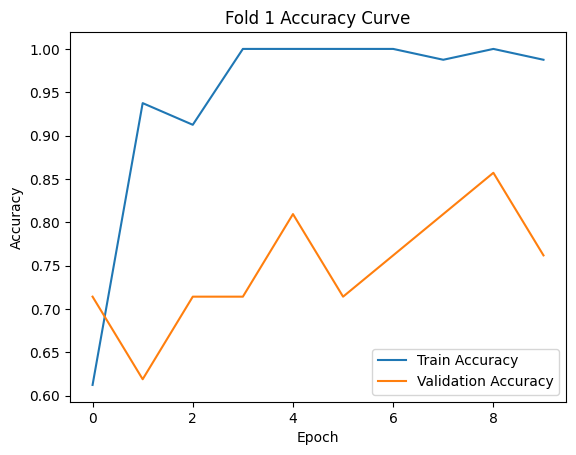


========== Fold 2 ==========
Epoch 1: Train=0.6049, Val=0.6000
Epoch 2: Train=0.8765, Val=0.7000
Epoch 3: Train=0.9753, Val=0.6500
Epoch 4: Train=0.9877, Val=0.6500
Epoch 5: Train=1.0000, Val=0.6000
Epoch 6: Train=0.9753, Val=0.6000
Epoch 7: Train=0.9877, Val=0.6500
Epoch 8: Train=1.0000, Val=0.6000
Epoch 9: Train=0.9877, Val=0.7000
Epoch 10: Train=1.0000, Val=0.6500


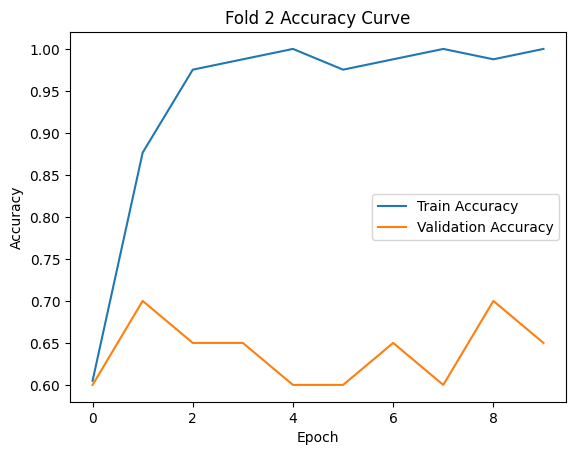


========== Fold 3 ==========
Epoch 1: Train=0.7037, Val=0.7500
Epoch 2: Train=0.9259, Val=0.7500
Epoch 3: Train=0.9877, Val=0.7500
Epoch 4: Train=1.0000, Val=0.7500
Epoch 5: Train=0.9877, Val=0.7000
Epoch 6: Train=1.0000, Val=0.7500
Epoch 7: Train=1.0000, Val=0.7500
Epoch 8: Train=1.0000, Val=0.7500
Epoch 9: Train=1.0000, Val=0.7500
Epoch 10: Train=1.0000, Val=0.7500


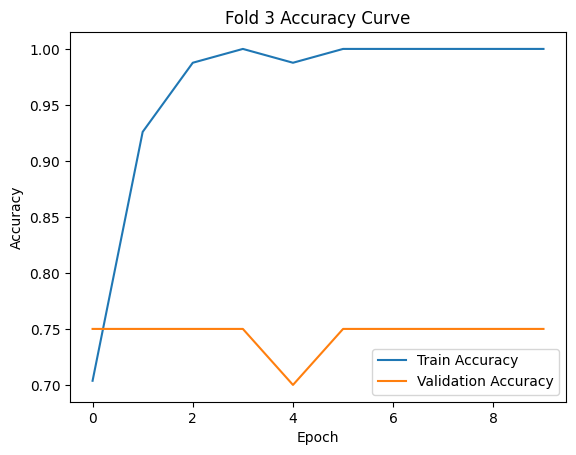


========== Fold 4 ==========
Epoch 1: Train=0.5679, Val=0.5500
Epoch 2: Train=0.9012, Val=0.6500
Epoch 3: Train=0.9383, Val=0.7500
Epoch 4: Train=0.9877, Val=0.7000
Epoch 5: Train=0.9753, Val=0.6500
Epoch 6: Train=0.9630, Val=0.7500
Epoch 7: Train=1.0000, Val=0.6500
Epoch 8: Train=0.9753, Val=0.5500
Epoch 9: Train=0.9877, Val=0.6500
Epoch 10: Train=0.9877, Val=0.6000


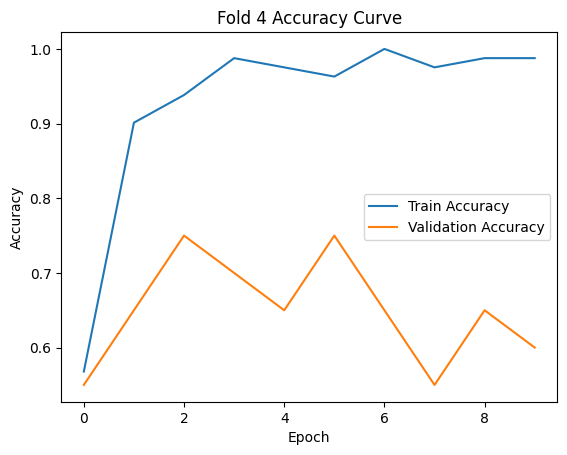


========== Fold 5 ==========
Epoch 1: Train=0.5062, Val=0.8000
Epoch 2: Train=0.8519, Val=0.5000
Epoch 3: Train=0.9630, Val=0.7500
Epoch 4: Train=0.9877, Val=0.7500
Epoch 5: Train=0.9877, Val=0.7500
Epoch 6: Train=0.9877, Val=0.7000
Epoch 7: Train=1.0000, Val=0.6500
Epoch 8: Train=1.0000, Val=0.6000
Epoch 9: Train=0.9630, Val=0.6000
Epoch 10: Train=0.9753, Val=0.7000


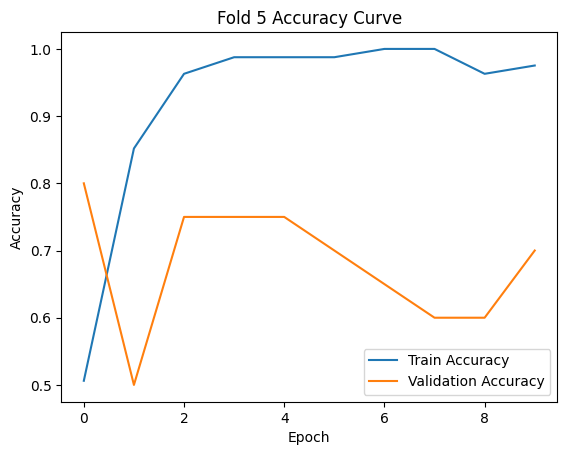


Average Validation Accuracy: 0.6923809523809524


In [ ]:
!pip install pydicom

from sklearn.model_selection import KFold
from torch.utils.data import DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
import torch

# --- Added dependencies to fix NameErrors ---
import pandas as pd
import os
import pydicom
import cv2
import numpy as np
from torch.utils.data import Dataset
import torchvision.models as models
import torch.nn as nn

# Define preprocess_dicom function (from cell 6uThrH6OM7bz)
def preprocess_dicom(path):
    try:
        dicom = pydicom.dcmread(path)
        img = dicom.pixel_array.astype(np.float32)

        # Ensure the image is 2D (height, width). If it's a 3D volume or has extra dimensions, return None.
        if img.ndim != 2:
            # print(f"Warning: Skipping non-2D DICOM file {path} with shape {img.shape}") # Mute for cleaner output
            return None # Indicate failure to process

        # Normalize
        img = (img - np.min(img)) / (np.max(img) - np.min(img))

        # Resize
        img = cv2.resize(img, (224, 224))

        # Convert to 3 channel
        img = np.stack([img, img, img], axis=0)
        return img
    except Exception as e:
        # print(f"Error processing DICOM file {path}: {e}") # Mute for cleaner output
        return None

# Define MRIDataset class (from cell OqBogB0zNm-Z)
class MRIDataset(Dataset):
    def __init__(self, subject_list):
        self.subject_list = subject_list

    def __len__(self):
        return len(self.subject_list)

    def __getitem__(self, idx):
        subject_path, label = self.subject_list[idx]

        # Recursively find all .dcm files within the subject's directory and its subdirectories
        all_dicom_paths = []
        for root, _, files in os.walk(subject_path):
            for file in files:
                if file.lower().endswith('.dcm'):
                    all_dicom_paths.append(os.path.join(root, file))

        if not all_dicom_paths:
            raise FileNotFoundError(f"No DICOM files found in {subject_path}")

        all_dicom_paths.sort()

        # Try to find a valid slice to preprocess
        img = None
        # Iterate through slices, starting from the middle, to find a valid one
        num_slices = len(all_dicom_paths)
        for i in range(num_slices):
            # Try middle, then middle + 1, middle - 1, middle + 2, middle - 2, etc.
            # This ensures we try to find a valid slice for the subject
            attempt_idx = (num_slices // 2 + (i // 2 if i % 2 == 0 else -(i + 1) // 2)) % num_slices

            middle_slice_path = all_dicom_paths[attempt_idx]
            img = preprocess_dicom(middle_slice_path)
            if img is not None:
                break

        if img is None:
            # If after trying all slices, no valid image was preprocessed
            # This case should ideally be handled by filtering subjects earlier
            raise ValueError(f"Could not preprocess any valid 2D DICOM image for subject {subject_path}")

        return torch.tensor(img, dtype=torch.float32), torch.tensor(label)

# Define get_resnet18 function (from cell 1XLPIBbWTHHy)
def get_resnet18():
    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model

# Helper function to check if a subject has at least one valid 2D DICOM slice
def has_valid_dicom_slice(subject_path):
    all_dicom_paths = []
    for root, _, files in os.walk(subject_path):
        for file in files:
            if file.lower().endswith('.dcm'):
                all_dicom_paths.append(os.path.join(root, file))
    if not all_dicom_paths:
        return False # No DICOM files found at all

    all_dicom_paths.sort()
    for i in range(len(all_dicom_paths)):
        attempt_idx = (len(all_dicom_paths) // 2 + (i // 2 if i % 2 == 0 else -(i + 1) // 2)) % len(all_dicom_paths)
        if preprocess_dicom(all_dicom_paths[attempt_idx]) is not None:
            return True # Found at least one valid slice
    return False # No valid slice found after trying all

# Define paths and subjects list (derived from cells TSGW6MIgJj76 and OKq9VBM0NvEK, with corrections)
csv_path1          = "/content/drive/MyDrive/new_Mri_2_22_2026.csv" # Use direct MyDrive path
csv_path2          = "/content/drive/MyDrive/controlled_MRI_scan_2_22_2026.csv" # Use direct MyDrive path

parkinson_df = pd.read_csv(csv_path1)
control_df = pd.read_csv(csv_path2)

subject_to_group = {}
for _, row in parkinson_df.iterrows():
    subject_to_group[row['Subject']] = 'PD'
for _, row in control_df.iterrows():
    subject_to_group[row['Subject']] = 'Control'

base_path = "/content/dataset"
data_root_path = os.path.join(base_path, "PPMI")

subjects = []
for subject_id_str in os.listdir(data_root_path):
    subject_folder_path = os.path.join(data_root_path, subject_id_str)
    if os.path.isdir(subject_folder_path):
        try:
            subject_id_int = int(subject_id_str)
            if subject_id_int in subject_to_group: # Check if this subject is in our mapped groups
                # Only add subject if it contains at least one valid 2D DICOM slice
                if has_valid_dicom_slice(subject_folder_path):
                    group = subject_to_group[subject_id_int]
                    label = 1 if group == 'PD' else 0 # 1 for Parkinson's, 0 for Control
                    subjects.append((subject_folder_path, label))
                else:
                    print(f"Skipping subject {subject_id_int} due to no valid 2D DICOM images.")
        except ValueError:
            pass # Skip non-integer folder names
# --- End of added dependencies ---

print(f"Total valid subjects for training: {len(subjects)}")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

fold_results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(subjects)): # 'subjects' is now defined

    print(f"\n========== Fold {fold+1} ==========")

    train_subjects = [subjects[i] for i in train_idx]
    val_subjects   = [subjects[i] for i in val_idx]

    # Corrected usage: MRIDataset instead of MRISubjectDataset
    train_dataset = MRIDataset(train_subjects)
    val_dataset   = MRIDataset(val_subjects)

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)

    model = get_resnet18().to(device) # 'get_resnet18' is now defined

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    train_acc_list = []
    val_acc_list = []

    epochs = 10

    for epoch in range(epochs):

        # Training
        model.train()
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_acc = correct_train / total_train
        train_acc_list.append(train_acc)

        # Validation
        model.eval()
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_acc = correct_val / total_val
        val_acc_list.append(val_acc)

        print(f"Epoch {epoch+1}: Train={train_acc:.4f}, Val={val_acc:.4f}")

    fold_results.append(val_acc_list[-1])

    # Plot Accuracy Curve for This Fold
    plt.figure()
    plt.plot(train_acc_list, label="Train Accuracy")
    plt.plot(val_acc_list, label="Validation Accuracy")
    plt.title(f"Fold {fold+1} Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

print("\nAverage Validation Accuracy:", sum(fold_results)/len(fold_results))

In [ ]:
print(f"Overall Average Validation Accuracy: {sum(fold_results)/len(fold_results):.2%}")

Overall Average Validation Accuracy: 69.24%
